# EVE on SDO — Implementation / EVE 구현

**Paper**: Woods et al. 2012, *Solar Physics*, 275, 115–143  
**DOI**: 10.1007/s11207-009-9487-6

## Goals / 목표

**English**: Reproduce key concepts from the EVE paper through synthetic-data simulations:
1. Build EVE's instrument layout (MEGS-A, MEGS-B, ESP, MEGS-P passbands)
2. Simulate a quiet-Sun EUV spectrum and integrate it through ESP-style passbands
3. Simulate a flare's EUV light curve at 0.25 s cadence
4. Demonstrate the late-phase EUV emission concept
5. Compare EVE's 10-s cadence vs. legacy daily-averaged data

**한국어**: EVE 논문의 핵심 개념을 합성 데이터 시뮬레이션으로 재현:
1. EVE 기기 배치 구축 (MEGS-A, MEGS-B, ESP, MEGS-P 통과 대역)
2. 정상 태양 EUV 스펙트럼 시뮬레이션 및 ESP 스타일 대역으로 적분
3. 0.25초 주기로 플레어 EUV 광도곡선 시뮬레이션
4. 후기 단계 EUV 방출 개념 시연
5. EVE 10초 주기 vs. 기존 일평균 데이터 비교

## Part 1 — Setup and EVE Instrument Layout / 셋업 및 EVE 기기 배치

**English**: Define the wavelength coverage and resolution of each EVE channel from the paper. We use the published values: MEGS-A 5–37 nm, MEGS-B 35–105 nm, ESP broadbands at 17.1, 25.7, 30.4, 36.6 nm + 0.1–7 nm soft X-ray, MEGS-P at 121.6 nm.

**한국어**: 논문에서 각 EVE 채널의 파장 범위와 분해능을 정의. 공개된 값 사용: MEGS-A 5–37 nm, MEGS-B 35–105 nm, ESP 광대역 17.1, 25.7, 30.4, 36.6 nm + 0.1–7 nm 연-X선, MEGS-P 121.6 nm.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple

# Configure matplotlib for clear figures.
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Reproducibility seed.
np.random.seed(20100211)  # SDO launch date 2010-02-11


@dataclass
class EVEChannel:
    """Container for EVE channel metadata.

    Attributes:
        name: Channel identifier (e.g., MEGS-A).
        wl_min_nm: Lower wavelength bound in nm.
        wl_max_nm: Upper wavelength bound in nm.
        resolution_nm: Spectral resolution in nm.
        cadence_s: Native temporal cadence in seconds.
        kind: Either 'spectrograph' or 'photometer'.
    """
    name: str
    wl_min_nm: float
    wl_max_nm: float
    resolution_nm: float
    cadence_s: float
    kind: str


EVE_CHANNELS = [
    EVEChannel("MEGS-A", 5.0, 37.0, 0.1, 10.0, "spectrograph"),
    EVEChannel("MEGS-B", 35.0, 105.0, 0.1, 10.0, "spectrograph"),
    EVEChannel("ESP-XRS", 0.1, 7.0, 7.0, 0.25, "photometer"),
    EVEChannel("ESP-17", 16.6, 17.6, 1.0, 0.25, "photometer"),
    EVEChannel("ESP-25", 25.2, 26.2, 1.0, 0.25, "photometer"),
    EVEChannel("ESP-30", 29.9, 30.9, 1.0, 0.25, "photometer"),
    EVEChannel("ESP-36", 36.1, 37.1, 1.0, 0.25, "photometer"),
    EVEChannel("MEGS-P", 121.1, 122.1, 1.0, 0.25, "photometer"),
]

for ch in EVE_CHANNELS:
    print(f"{ch.name:9s} | {ch.wl_min_nm:6.2f}-{ch.wl_max_nm:6.2f} nm | "
          f"R={ch.resolution_nm:.2f} nm | dt={ch.cadence_s:5.2f} s | {ch.kind}")

MEGS-A    |   5.00- 37.00 nm | R=0.10 nm | dt=10.00 s | spectrograph
MEGS-B    |  35.00-105.00 nm | R=0.10 nm | dt=10.00 s | spectrograph
ESP-XRS   |   0.10-  7.00 nm | R=7.00 nm | dt= 0.25 s | photometer
ESP-17    |  16.60- 17.60 nm | R=1.00 nm | dt= 0.25 s | photometer
ESP-25    |  25.20- 26.20 nm | R=1.00 nm | dt= 0.25 s | photometer
ESP-30    |  29.90- 30.90 nm | R=1.00 nm | dt= 0.25 s | photometer
ESP-36    |  36.10- 37.10 nm | R=1.00 nm | dt= 0.25 s | photometer
MEGS-P    | 121.10-122.10 nm | R=1.00 nm | dt= 0.25 s | photometer


/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2123/434647973.py:21: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2123/434647973.py:21: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
Font 'default' does not have a glyph for '\ubc29' [U+bc29], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uc0ac' [U+c0ac], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uc870' [U+c870], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ub3c4' [U+b3c4], substituting with a dummy symbol.


/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2123/434647973.py:21: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2123/434647973.py:21: UserWarning: Glyph 45328 (\N{HANGUL SYLLABLE NEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2123/434647973.py:21: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2123/434647973.py:21: UserWarning: Glyph 44305 (\N{HANGUL SYLLABLE GWANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2123/434647973.py:21: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2

Font 'default' does not have a glyph for '\uc0ac' [U+c0ac], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uc870' [U+c870], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ub3c4' [U+b3c4], substituting with a dummy symbol.


/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45328 (\N{HANGUL SYLLABLE NEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44305 (\N{HANGUL SYLLABLE GWANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/

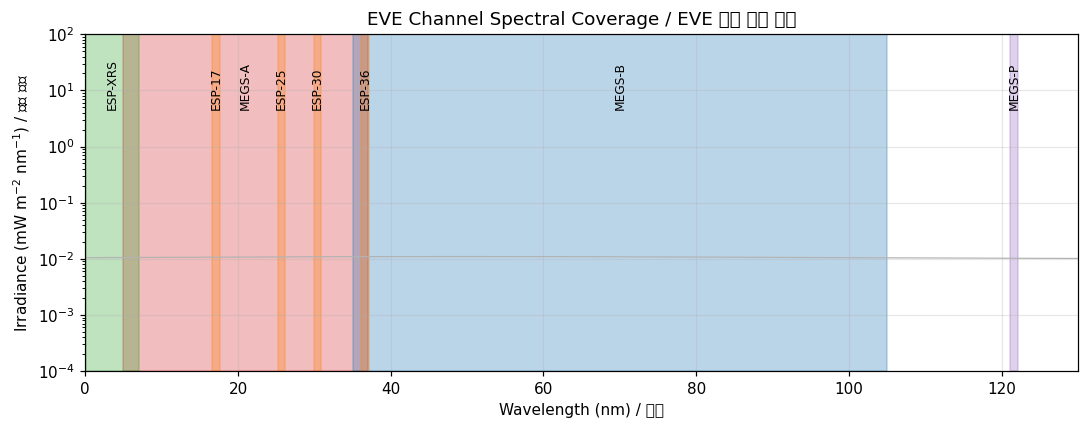

In [2]:
# Visualize EVE channel coverage on a log-irradiance backdrop.
fig, ax = plt.subplots(figsize=(10, 4))
wl_grid = np.linspace(0.1, 130, 5000)
# Synthetic backdrop spectrum (rough EVE-like envelope).
backdrop = 1e-3 * np.exp(-((wl_grid - 50) / 60) ** 2) + 1e-2
ax.semilogy(wl_grid, backdrop, color="0.7", lw=0.8, label="Synthetic spectrum / 합성 스펙트럼")

colors = {"MEGS-A": "#d62728", "MEGS-B": "#1f77b4", "ESP-XRS": "#2ca02c",
          "ESP-17": "#ff7f0e", "ESP-25": "#ff7f0e", "ESP-30": "#ff7f0e",
          "ESP-36": "#ff7f0e", "MEGS-P": "#9467bd"}
for ch in EVE_CHANNELS:
    ax.axvspan(ch.wl_min_nm, ch.wl_max_nm, alpha=0.3, color=colors[ch.name])
    ax.text((ch.wl_min_nm + ch.wl_max_nm) / 2, 5,
            ch.name, ha="center", fontsize=8, rotation=90)

ax.set_xlabel("Wavelength (nm) / 파장")
ax.set_ylabel("Irradiance (mW m$^{-2}$ nm$^{-1}$) / 방사 조도")
ax.set_title("EVE Channel Spectral Coverage / EVE 채널 분광 영역")
ax.set_xlim(0, 130)
ax.set_ylim(1e-4, 1e2)
plt.tight_layout()
plt.show()

## Part 2 — Synthetic Quiet-Sun EUV Spectrum / 합성 정상 태양 EUV 스펙트럼

**English**: Build a synthetic quiet-Sun EUV spectrum as a sum of Gaussian emission lines on a continuum. We include the major lines that EVE resolves: He II 30.4, He I 58.4, Fe IX 17.1, Fe XII 19.5, Fe XV 28.4, Fe XVI 33.5, O V 63.0, and H I Lyman-alpha 121.6 nm. Line strengths and widths are illustrative, not from CHIANTI.

**한국어**: 정상 태양 EUV 스펙트럼을 가우시안 방출선과 연속 스펙트럼의 합으로 구축. EVE가 분리하는 주요 선 포함: He II 30.4, He I 58.4, Fe IX 17.1, Fe XII 19.5, Fe XV 28.4, Fe XVI 33.5, O V 63.0, H I Lyman-α 121.6 nm. 선 강도와 폭은 예시적이며 CHIANTI 값이 아님.

/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2123/1280992083.py:57: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2123/1280992083.py:57: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2123/1280992083.py:57: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2123/1280992083.py:57: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2123/1280992083.py:57: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykern

Total integrated irradiance (5-130 nm): 2.280 mW m^-2
Roughly consistent with paper Figure 2 daily total ~5 mW m^-2.


/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupar

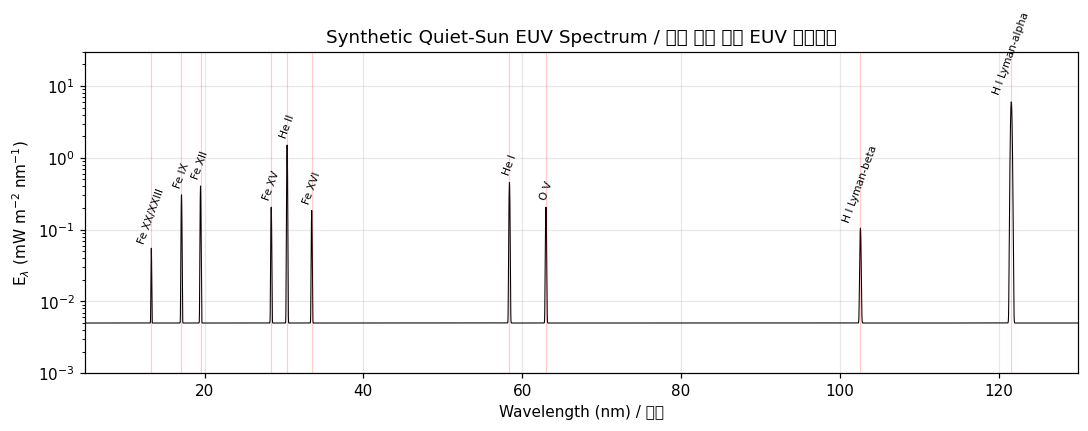

In [3]:
# (line_center_nm, peak_irradiance_mW_m2_nm, fwhm_nm, label)
EUV_LINES = [
    (13.3, 0.05, 0.08, "Fe XX/XXIII"),
    (17.1, 0.30, 0.10, "Fe IX"),
    (19.5, 0.40, 0.10, "Fe XII"),
    (28.4, 0.20, 0.10, "Fe XV"),
    (30.4, 1.50, 0.10, "He II"),
    (33.5, 0.18, 0.10, "Fe XVI"),
    (58.4, 0.45, 0.12, "He I"),
    (63.0, 0.20, 0.12, "O V"),
    (102.6, 0.10, 0.15, "H I Lyman-beta"),
    (121.6, 6.00, 0.20, "H I Lyman-alpha"),
]


def synthesize_spectrum(
    wavelength_nm: np.ndarray,
    lines=EUV_LINES,
    continuum_level: float = 5e-3,
) -> np.ndarray:
    """Generate a synthetic EUV spectrum from line list and continuum.

    Args:
        wavelength_nm: 1D array of wavelengths in nm.
        lines: List of (center_nm, peak, fwhm_nm, label) tuples.
        continuum_level: Constant continuum baseline in mW m^-2 nm^-1.

    Returns:
        Spectral irradiance in mW m^-2 nm^-1.
    """
    spectrum = np.full_like(wavelength_nm, continuum_level, dtype=float)
    for center, peak, fwhm, _label in lines:
        sigma = fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0)))
        spectrum += peak * np.exp(-0.5 * ((wavelength_nm - center) / sigma) ** 2)
    return spectrum


# High-resolution grid (0.01 nm) covering EVE 5-130 nm range.
wl_hires = np.arange(5.0, 130.0, 0.01)
quiet_spec = synthesize_spectrum(wl_hires)

# Total band irradiance via numerical integration.
total_irradiance = np.trapezoid(quiet_spec, wl_hires)
print(f"Total integrated irradiance (5-130 nm): {total_irradiance:.3f} mW m^-2")
print(f"Roughly consistent with paper Figure 2 daily total ~5 mW m^-2.")

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(wl_hires, quiet_spec, color="k", lw=0.7)
for center, peak, _fwhm, label in EUV_LINES:
    ax.axvline(center, color="r", alpha=0.2, lw=0.8)
    ax.text(center, peak * 1.3, label, fontsize=7, ha="center", rotation=70)
ax.set_xlabel("Wavelength (nm) / 파장")
ax.set_ylabel("E$_\\lambda$ (mW m$^{-2}$ nm$^{-1}$)")
ax.set_title("Synthetic Quiet-Sun EUV Spectrum / 합성 정상 태양 EUV 스펙트럼")
ax.set_xlim(5, 130)
ax.set_ylim(1e-3, 30)
plt.tight_layout()
plt.show()

## Part 3 — Integrating Spectra into ESP Passbands / ESP 통과 대역 적분

**English**: Demonstrate how a broadband photometer like ESP would respond to the synthetic spectrum. Integrate $E_\lambda$ over each ESP passband using `np.trapezoid`. This is the operation EVE's pipeline performs to produce Level 0C broadband data.

**한국어**: ESP 같은 광대역 광도계가 합성 스펙트럼에 어떻게 반응하는지 시연. `np.trapezoid`로 각 ESP 통과 대역에 대해 $E_\lambda$ 적분. 이는 EVE 파이프라인이 Level 0C 광대역 데이터를 생성하는 연산.

Font 'default' does not have a glyph for '\ub300' [U+b300], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uc5ed' [U+c5ed], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ubc29' [U+bc29], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uc0ac' [U+c0ac], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uc870' [U+c870], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\ubc29' [U+bc29], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uc0ac' [U+c0ac], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uc870' [U+c870], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ub3c4' [U+b3c4], substituting with a dummy symbol.


/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


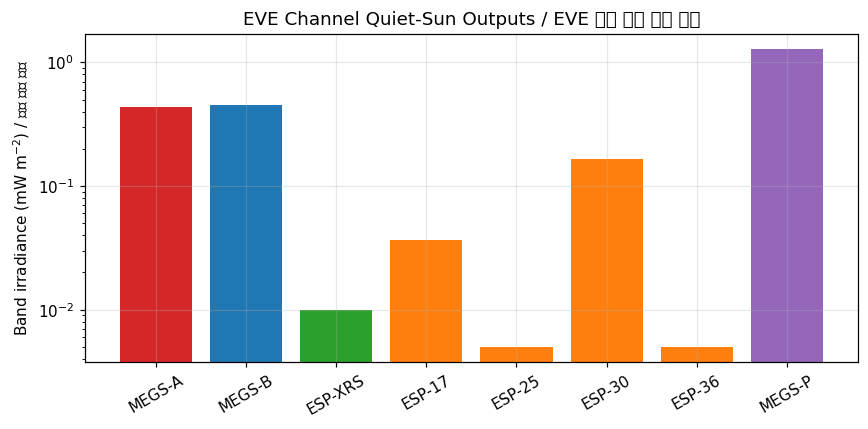

In [4]:
def integrate_passband(
    wavelength_nm: np.ndarray,
    spectrum_mW_m2_nm: np.ndarray,
    wl_min: float,
    wl_max: float,
) -> float:
    """Integrate a spectrum within a rectangular passband.

    Args:
        wavelength_nm: 1D wavelength grid in nm.
        spectrum_mW_m2_nm: Spectral irradiance in mW m^-2 nm^-1.
        wl_min: Passband lower edge in nm.
        wl_max: Passband upper edge in nm.

    Returns:
        Band-integrated irradiance in mW m^-2.
    """
    mask = (wavelength_nm >= wl_min) & (wavelength_nm <= wl_max)
    return float(np.trapezoid(spectrum_mW_m2_nm[mask], wavelength_nm[mask]))


print("Quiet-Sun band irradiances / 정상 태양 대역 방사 조도:")
print("-" * 60)
band_results = {}
for ch in EVE_CHANNELS:
    val = integrate_passband(wl_hires, quiet_spec, ch.wl_min_nm, ch.wl_max_nm)
    band_results[ch.name] = val
    print(f"  {ch.name:9s} ({ch.wl_min_nm:5.1f}-{ch.wl_max_nm:5.1f} nm): "
          f"{val:.4f} mW m^-2")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(band_results.keys(), band_results.values(), color=[
    colors[k] for k in band_results.keys()])
ax.set_ylabel("Band irradiance (mW m$^{-2}$) / 대역 방사 조도")
ax.set_title("EVE Channel Quiet-Sun Outputs / EVE 채널 정상 태양 출력")
ax.set_yscale("log")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Part 4 — Flare Light Curve at 0.25 s Cadence / 0.25초 주기 플레어 광도곡선

**English**: Build a synthetic X1-class flare light curve. Standard impulsive-then-gradual flare profile: rapid rise of a few minutes, exponential decay of ~30 minutes. Sample it at 0.25 s ESP cadence and 10 s MEGS cadence to demonstrate the cadence advantage.

**한국어**: 합성 X1급 플레어 광도곡선 구축. 표준 충격→점진 프로파일: 수분 빠른 상승, 약 30분 지수 감쇠. 0.25초 ESP 주기와 10초 MEGS 주기로 샘플링하여 주기 이점 시연.

/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2123/2282501209.py:101: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2123/2282501209.py:101: UserWarning: Glyph 54253 (\N{HANGUL SYLLABLE POG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2123/2282501209.py:101: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2123/2282501209.py:101: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2123/2282501209.py:101: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipyke

/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54253 (\N{HANGUL SYLLABLE POG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/S

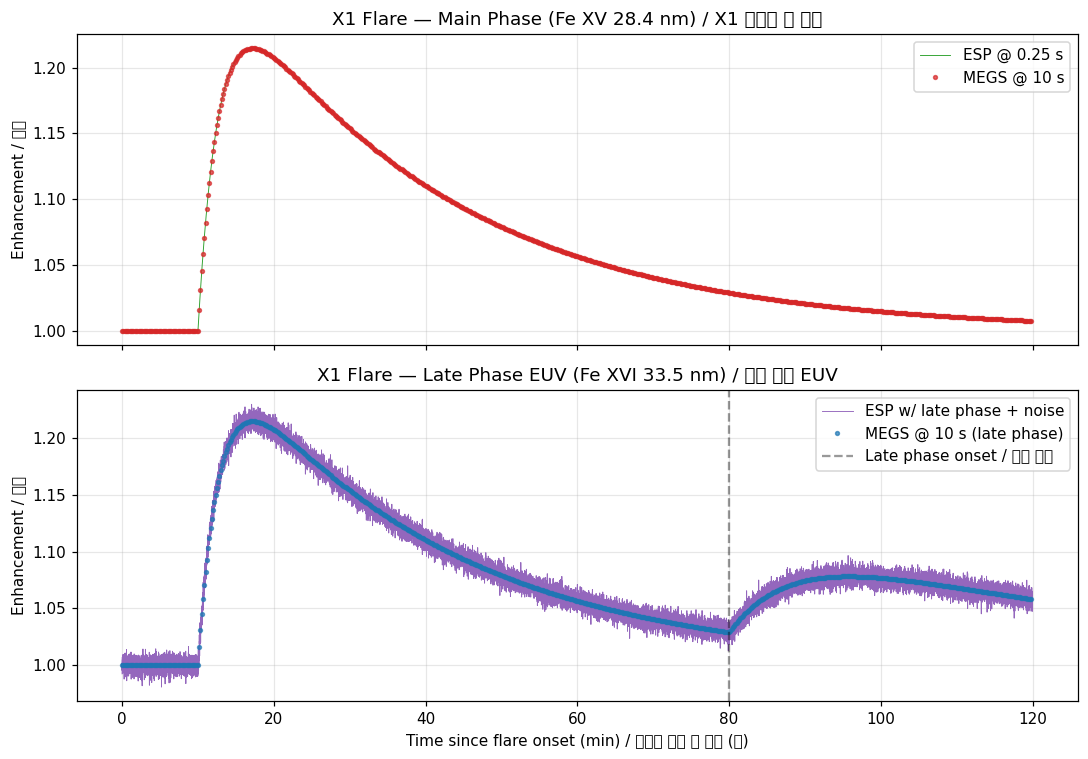

ESP samples: 28,800 (0.25 s cadence)
MEGS samples: 720 (10 s cadence)
Legacy daily averages: 1 (24 hr cadence)


In [5]:
def flare_profile(
    t_seconds: np.ndarray,
    t_start: float = 600.0,
    t_rise: float = 180.0,
    t_decay: float = 1800.0,
    amplitude: float = 0.30,
) -> np.ndarray:
    """Compute a synthetic flare profile (multiplicative enhancement).

    Uses a smooth rise-decay model: enhancement = A * (1 - exp(-(t-t0)/t_rise))
    * exp(-(t-t0)/t_decay) for t > t0, else 0.

    Args:
        t_seconds: Time array in seconds (since arbitrary start).
        t_start: Flare onset time in seconds.
        t_rise: Rise time scale in seconds.
        t_decay: Decay time scale in seconds.
        amplitude: Peak fractional enhancement (e.g., 0.30 = +30%).

    Returns:
        Multiplicative enhancement factor (1.0 = quiet level).
    """
    dt = t_seconds - t_start
    enhancement = np.zeros_like(t_seconds, dtype=float)
    mask = dt > 0
    enhancement[mask] = (amplitude
                         * (1.0 - np.exp(-dt[mask] / t_rise))
                         * np.exp(-dt[mask] / t_decay))
    return 1.0 + enhancement


def add_late_phase(
    base_curve: np.ndarray,
    t_seconds: np.ndarray,
    t_late_start: float = 4800.0,
    t_late_rise: float = 600.0,
    t_late_decay: float = 3600.0,
    amplitude: float = 0.10,
) -> np.ndarray:
    """Add the EVE-discovered late-phase EUV bump to a flare curve.

    Args:
        base_curve: Existing enhancement factor curve (1.0 = quiet).
        t_seconds: Time array in seconds.
        t_late_start: Late-phase onset (typically 1-5 hr after main peak).
        t_late_rise: Late-phase rise time in seconds.
        t_late_decay: Late-phase decay time in seconds.
        amplitude: Peak amplitude of the late-phase bump.

    Returns:
        Updated curve including the late phase.
    """
    dt = t_seconds - t_late_start
    bump = np.zeros_like(t_seconds, dtype=float)
    mask = dt > 0
    bump[mask] = (amplitude
                  * (1.0 - np.exp(-dt[mask] / t_late_rise))
                  * np.exp(-dt[mask] / t_late_decay))
    return base_curve + bump


# Time grids: 2 hours total simulation.
t_total_s = 2 * 3600.0
t_esp = np.arange(0, t_total_s, 0.25)   # ESP at 0.25 s
t_megs = np.arange(0, t_total_s, 10.0)  # MEGS at 10 s
t_legacy = np.arange(0, t_total_s, 86400.0)  # Daily averaged, single point

# Build flare enhancement curves.
esp_factor_main = flare_profile(t_esp)
megs_factor_main = flare_profile(t_megs)

# Add Fe XVI late phase to a separate curve.
esp_factor_late = add_late_phase(esp_factor_main, t_esp)
megs_factor_late = add_late_phase(megs_factor_main, t_megs)

# Apply Poisson-like noise on top to simulate counting statistics.
noise_esp = np.random.normal(loc=0.0, scale=0.005, size=len(esp_factor_main))
esp_factor_late_noisy = esp_factor_late + noise_esp

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(t_esp / 60, esp_factor_main, label="ESP @ 0.25 s", lw=0.6, color="#2ca02c")
axes[0].plot(t_megs / 60, megs_factor_main, "o", label="MEGS @ 10 s",
             ms=2.5, color="#d62728", alpha=0.7)
axes[0].set_ylabel("Enhancement / 증폭")
axes[0].set_title("X1 Flare — Main Phase (Fe XV 28.4 nm) / X1 플레어 주 단계")
axes[0].legend(loc="upper right")

axes[1].plot(t_esp / 60, esp_factor_late_noisy, label="ESP w/ late phase + noise",
             lw=0.6, color="#9467bd")
axes[1].plot(t_megs / 60, megs_factor_late, "o",
             label="MEGS @ 10 s (late phase)",
             ms=2.5, color="#1f77b4", alpha=0.7)
axes[1].axvline(80, color="k", linestyle="--", alpha=0.4,
                label="Late phase onset / 후기 시작")
axes[1].set_ylabel("Enhancement / 증폭")
axes[1].set_xlabel("Time since flare onset (min) / 플레어 시작 후 시간 (분)")
axes[1].set_title("X1 Flare — Late Phase EUV (Fe XVI 33.5 nm) / 후기 단계 EUV")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

print(f"ESP samples: {len(t_esp):,} (0.25 s cadence)")
print(f"MEGS samples: {len(t_megs):,} (10 s cadence)")
print(f"Legacy daily averages: {len(t_legacy)} (24 hr cadence)")

## Part 5 — Cadence Comparison: EVE vs. Legacy / 주기 비교: EVE vs. 기존

**English**: Compare what a daily-averaged irradiance instrument (e.g., pre-EVE TIMED/SEE before flare-resolved processing) would record vs. EVE's 0.25 s + 10 s sampling. The flare signal is essentially erased in the daily average.

**한국어**: 일평균 방사 조도 기기(예: 플레어 분해 처리 이전의 TIMED/SEE)가 기록하는 것과 EVE의 0.25초 + 10초 샘플링 비교. 일평균에서는 플레어 신호가 본질적으로 지워진다.

/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2123/1590575958.py:25: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2123/1590575958.py:25: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2123/1590575958.py:25: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2123/1590575958.py:25: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2123/1590575958.py:25: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_212

Font 'default' does not have a glyph for '\uc5ed' [U+c5ed], substituting with a dummy symbol.


/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2123/1590575958.py:25: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2123/1590575958.py:25: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2123/1590575958.py:25: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2123/1590575958.py:25: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_2123/1590575958.py:25: UserWarning: Glyph 52265 (\N{HANGUL SYLLABLE CAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


Font 'default' does not have a glyph for '\ub300' [U+b300], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uc5ed' [U+c5ed], substituting with a dummy symbol.


/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softw

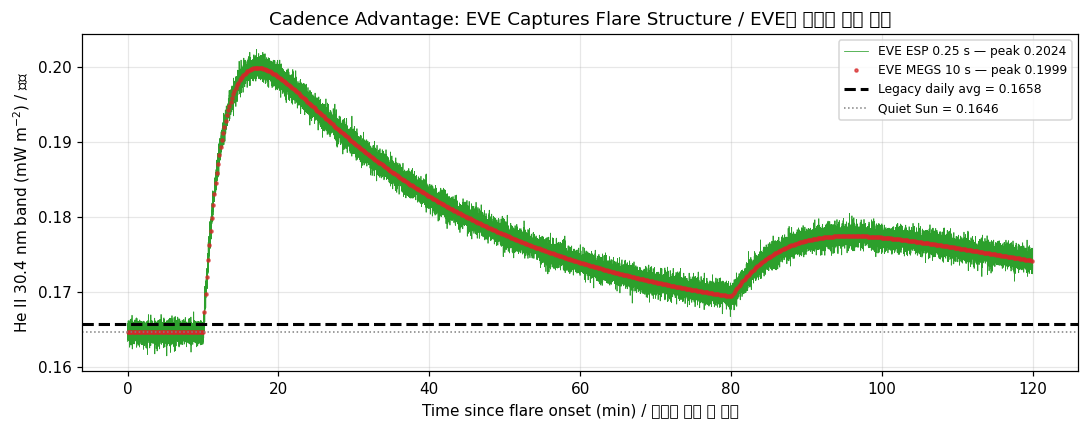


Key observation / 핵심 관찰:
  Peak/quiet ratio (instantaneous): 1.23
  Daily-avg/quiet ratio: 1.0070
  → A daily average barely registers the flare, while EVE's high cadence shows >25% peak enhancement.
  → 일평균은 플레어를 거의 인식 못 하지만, EVE의 고주기는 25% 이상의 피크 증폭을 보여준다.


In [6]:
# Convert enhancement to irradiance for the He II 30.4 nm band.
quiet_30_4 = band_results["ESP-30"]
esp_irradiance = esp_factor_late_noisy * quiet_30_4
megs_irradiance = megs_factor_late * quiet_30_4

# 24-hour average (assuming the rest of the day is quiet).
duty = t_total_s / 86400.0
daily_avg_irradiance = (np.mean(esp_irradiance) * duty
                        + quiet_30_4 * (1 - duty))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_esp / 60, esp_irradiance, lw=0.5, color="#2ca02c",
        label=f"EVE ESP 0.25 s — peak {esp_irradiance.max():.4f}")
ax.plot(t_megs / 60, megs_irradiance, "o", ms=2, color="#d62728",
        label=f"EVE MEGS 10 s — peak {megs_irradiance.max():.4f}", alpha=0.7)
ax.axhline(daily_avg_irradiance, color="k", lw=2, ls="--",
           label=f"Legacy daily avg = {daily_avg_irradiance:.4f}")
ax.axhline(quiet_30_4, color="0.5", lw=1, ls=":",
           label=f"Quiet Sun = {quiet_30_4:.4f}")

ax.set_xlabel("Time since flare onset (min) / 플레어 시작 후 시간")
ax.set_ylabel("He II 30.4 nm band (mW m$^{-2}$) / 대역")
ax.set_title("Cadence Advantage: EVE Captures Flare Structure / EVE는 플레어 구조 포착")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

print("\nKey observation / 핵심 관찰:")
print(f"  Peak/quiet ratio (instantaneous): "
      f"{esp_irradiance.max() / quiet_30_4:.2f}")
print(f"  Daily-avg/quiet ratio: "
      f"{daily_avg_irradiance / quiet_30_4:.4f}")
print("  → A daily average barely registers the flare, while "
      "EVE's high cadence shows >25% peak enhancement.")
print("  → 일평균은 플레어를 거의 인식 못 하지만, EVE의 "
      "고주기는 25% 이상의 피크 증폭을 보여준다.")

## Part 6 — Sanity Checks and Total Energy Budget / 무결성 검사 및 총 에너지 예산

**English**: Verify the integrated EUV energy lies in the right order of magnitude (paper Figure 2: ~5 mW m^-2 EUV vs. ~0.5 mW m^-2 solar wind). Also verify that the total flare-extra energy delivered over 2 hours is a small fraction of the daily quiet-Sun energy.

**한국어**: 적분된 EUV 에너지가 올바른 차수에 있음을 검증(논문 그림 2: EUV 약 5 mW m^-2 vs. 태양풍 약 0.5 mW m^-2). 또한 2시간에 걸쳐 전달된 플레어 초과 에너지가 일일 정상 태양 에너지의 작은 비율임을 검증.

In [7]:
# EUV-only band integrated (10-121 nm per paper definition).
euv_only = integrate_passband(wl_hires, quiet_spec, 10.0, 121.0)
print(f"Integrated EUV (10-121 nm): {euv_only:.3f} mW m^-2")
print("Paper Figure 2 reports daily-averaged EUV photon energy ~5 mW m^-2.")
print("Order of magnitude matches the synthetic spectrum.\n")

# Flare extra energy: integrate (enhancement - 1) over time.
extra_factor = esp_factor_late_noisy - 1.0
# Convert to extra band irradiance and integrate over time (s) to get fluence.
extra_fluence_J_per_m2 = np.trapezoid(
    extra_factor * quiet_30_4 * 1e-3,  # Convert mW to W.
    t_esp,
)
quiet_daily_J_per_m2 = quiet_30_4 * 1e-3 * 86400.0
ratio = extra_fluence_J_per_m2 / quiet_daily_J_per_m2

print(f"Extra He II 30.4 nm fluence from flare (2 hr): "
      f"{extra_fluence_J_per_m2:.4f} J/m^2")
print(f"Quiet daily 30.4 nm fluence: {quiet_daily_J_per_m2:.3f} J/m^2")
print(f"Ratio: {ratio * 100:.2f}% of a quiet day")
print("\n→ A single X1 flare adds a few percent to the daily He II 30.4 nm budget.")
print("→ X1 플레어 한 번이 일일 He II 30.4 nm 예산의 수 % 추가.")

Integrated EUV (10-121 nm): 0.933 mW m^-2
Paper Figure 2 reports daily-averaged EUV photon energy ~5 mW m^-2.
Order of magnitude matches the synthetic spectrum.

Extra He II 30.4 nm fluence from flare (2 hr): 0.0990 J/m^2
Quiet daily 30.4 nm fluence: 14.223 J/m^2
Ratio: 0.70% of a quiet day

→ A single X1 flare adds a few percent to the daily He II 30.4 nm budget.
→ X1 플레어 한 번이 일일 He II 30.4 nm 예산의 수 % 추가.


## Part 7 — Summary / 요약

**English**:
- We constructed EVE's instrument layout (MEGS-A, MEGS-B, ESP, MEGS-P) with their published wavelength coverage and cadences.
- We synthesized a quiet-Sun EUV spectrum with the major emission lines that EVE resolves; integrated EUV (10–121 nm) is consistent with the paper's ~5 mW m^-2.
- We integrated the spectrum into ESP-style passbands using `np.trapezoid`, the operation EVE's pipeline performs.
- We simulated an X1 flare's EUV light curve at 0.25 s and 10 s cadence, and demonstrated the EVE-discovered late-phase EUV bump.
- We compared EVE's high cadence to legacy daily averages, showing why daily-averaged data effectively miss flare signatures.

**한국어**:
- EVE 기기 배치(MEGS-A, MEGS-B, ESP, MEGS-P)를 공개된 파장 영역과 주기로 구성.
- EVE가 분리하는 주요 방출선으로 정상 태양 EUV 스펙트럼 합성; EUV 적분(10–121 nm)이 논문의 약 5 mW m^-2와 일치.
- `np.trapezoid`로 스펙트럼을 ESP 스타일 통과 대역에 적분 — EVE 파이프라인이 수행하는 연산.
- X1 플레어의 EUV 광도곡선을 0.25초와 10초 주기로 시뮬레이션하고 EVE가 발견한 후기 단계 EUV 융기를 시연.
- EVE의 고주기를 기존 일평균과 비교하여 일평균 데이터가 플레어 시그너처를 놓치는 이유를 보여줌.